# 1. Lab Overview

This first lab introduces the computational representation of digital images and the basic operations used throughout a Computer Vision course. You will work step-by-step in **Google Colab** using **Python**, **NumPy**, **OpenCV**, and **Matplotlib**.

---

## 1.1 Learning Outcomes

By the end of this lab, you will be able to:

*   **Environment Setup:** Create and organize a Google Colab notebook specifically for Computer Vision.
*   **Data Representation:** Explain a digital image as a numerical `NumPy` array structure.
*   **File Operations:** Read, display, inspect, modify, and save digital images.
*   **Color Spaces:** Understand grayscale and color image profiles, including the crucial `BGR` vs. `RGB` channel ordering.
*   **Pixel Manipulation:** Programmatically access and modify individual pixel coordinates and discrete image channels.
*   **Mathematical Operations:** Perform element-wise arithmetic operations including addition, subtraction, scaling, blending/averaging, and absolute difference calculations.
*   **Data Constraints:** Understand data overflow and saturation conditions unique to `8-bit` (`uint8`) image arithmetic.
*   **Logical Operations:** Perform bitwise calculations using `AND`, `OR`, `XOR`, and `NOT` operations.
*   **Image Segmentation:** Create binary masks and deploy them to programmatically isolate a **Region of Interest (ROI)**.
*   **Critical Analysis:** Successfully interpret program output data and formulate technical observations rather than simply copying code structures.


In [1]:
# Import libraries
import cv2

In [3]:
import numpy as np

In [4]:
import matplotlib.pyplot as plt


In [6]:
# Check versions
print("OpenCV:", cv2.__version__)
print("NumPy:", np.__version__)


OpenCV: 4.14.0
NumPy: 2.1.3


Shape: (300, 400)
Data type: uint8


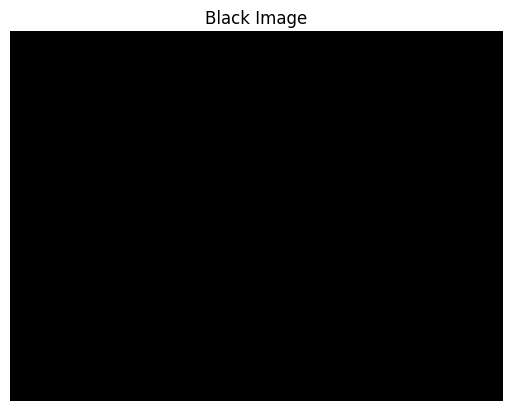

In [7]:
black = np.zeros((300, 400), dtype=np.uint8)

print("Shape:", black.shape)
print("Data type:", black.dtype)

plt.imshow(black, cmap="gray")
plt.title("Black Image")
plt.axis("off")
plt.show()


In [8]:
# Upload an image
from google.colab import files

uploaded = files.upload()


Saving lion.jpg to lion.jpg


In [10]:
# Read the image
img = cv2.imread("lion.jpg")

print(type(img))
print(img.shape)
print(img.dtype)


<class 'numpy.ndarray'>
(1004, 1500, 3)
uint8


Text(0.5, 1.0, 'Original Image')

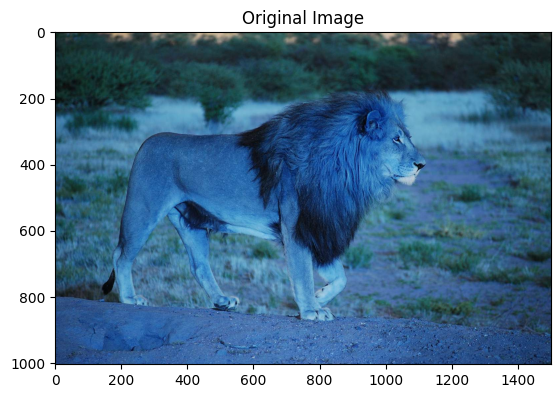

In [11]:
# OpenCV reads color images as BGR
# Matplotlib expects RGB

# img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.title("Original Image")


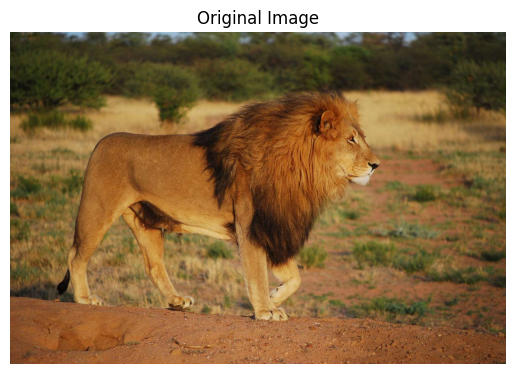

In [12]:
# OpenCV reads color images as BGR
# Matplotlib expects RGB

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img_rgb)
plt.title("Original Image")
plt.axis("off")
plt.show()



In [14]:
# Inspect properties
height, width, channels = img.shape

print("Height:", height)
print("Width:", width)
print("Channels:", channels)
print("Shape:", img.shape)
print("Data type:", img.dtype)
print("Total array elements:", img.size)
print("Memory bytes:", img.nbytes)


Height: 1004
Width: 1500
Channels: 3
Shape: (1004, 1500, 3)
Data type: uint8
Total array elements: 4518000
Memory bytes: 4518000


In [15]:
# Save an image
cv2.imwrite("output_copy.jpg", img)
print("Image saved successfully.")

files.download("output_copy.jpg")


Image saved successfully.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Color shape: (1004, 1500, 3)
Grayscale shape: (1004, 1500)


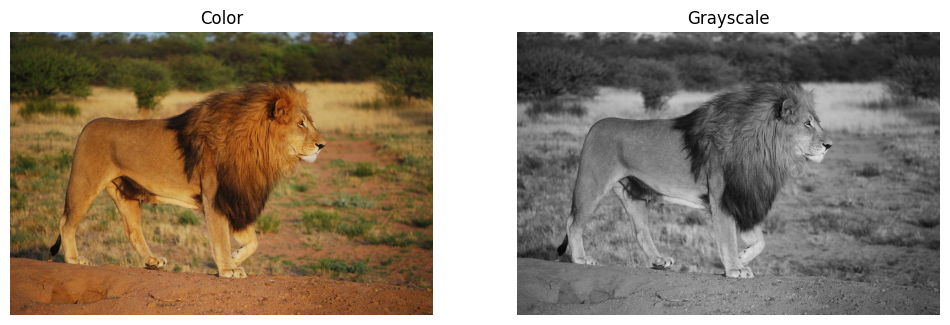

In [16]:
# Convert color to grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

print("Color shape:", img.shape)
print("Grayscale shape:", gray.shape)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(img_rgb)
plt.title("Color")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(gray, cmap="gray")
plt.title("Grayscale")
plt.axis("off")

plt.show()


In [17]:
# Access individual pixels
# NumPy uses [row, column], i.e. [y, x]
y, x = 100, 150

print("Grayscale pixel:", gray[y, x])
print("BGR pixel:", img[y, x])


Grayscale pixel: 46
BGR pixel: [21 51 46]


In [18]:
# Inspect B, G and R
B = img[y, x, 0]
G = img[y, x, 1]
R = img[y, x, 2]

print("B:", B)
print("G:", G)
print("R:", R)


B: 21
G: 51
R: 46


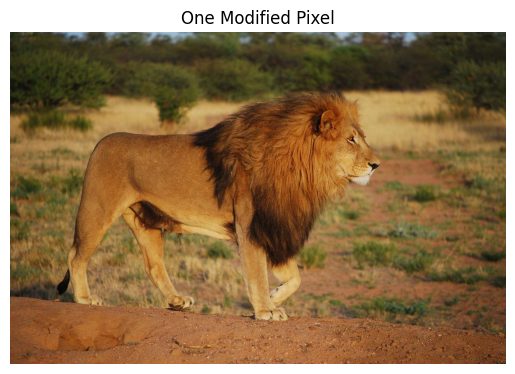

In [19]:
# Modify a pixel
modified = img.copy()

# Pure red in OpenCV BGR order
modified[100, 150] = [0, 0, 255]

modified_rgb = cv2.cvtColor(modified, cv2.COLOR_BGR2RGB)

plt.imshow(modified_rgb)
plt.title("One Modified Pixel")
plt.axis("off")
plt.show()


In [20]:
# Split channels
B, G, R = cv2.split(img)

print("B shape:", B.shape)
print("G shape:", G.shape)
print("R shape:", R.shape)


B shape: (1004, 1500)
G shape: (1004, 1500)
R shape: (1004, 1500)


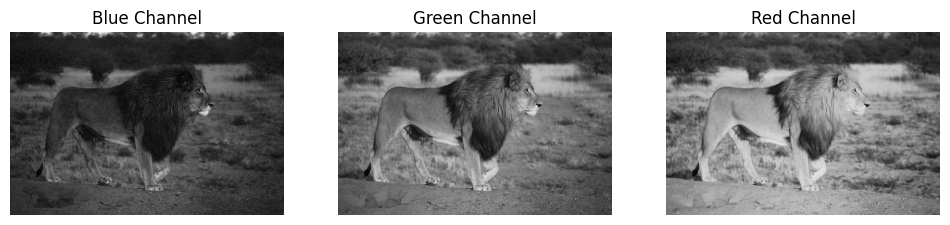

In [21]:
# Display channels
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(B, cmap="gray")
plt.title("Blue Channel")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(G, cmap="gray")
plt.title("Green Channel")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(R, cmap="gray")
plt.title("Red Channel")
plt.axis("off")

plt.show()


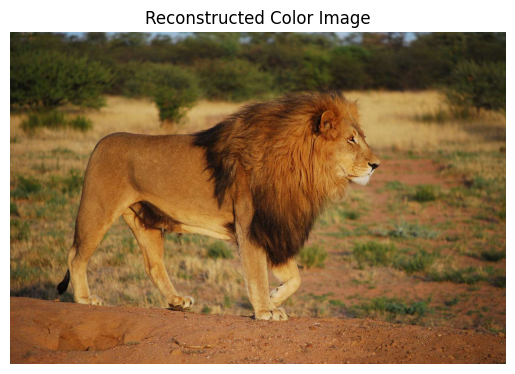

In [22]:
# Reconstruct
merged = cv2.merge([B, G, R])
merged_rgb = cv2.cvtColor(merged, cv2.COLOR_BGR2RGB)

plt.imshow(merged_rgb)
plt.title("Reconstructed Color Image")
plt.axis("off")
plt.show()


## Mathematical Operations on Images

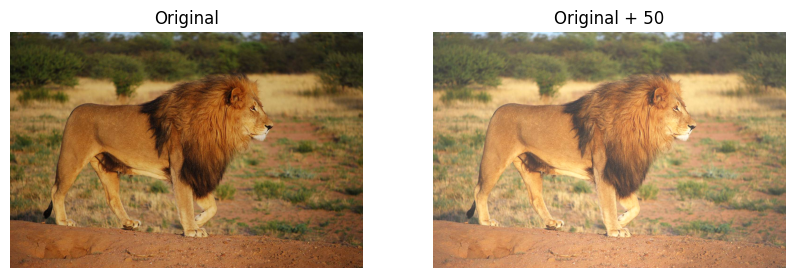

In [23]:
# Addition
bright = cv2.add(img, 50)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(img_rgb); plt.title("Original"); plt.axis("off")
plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(bright, cv2.COLOR_BGR2RGB)); plt.title("Original + 50"); plt.axis("off")
plt.show()


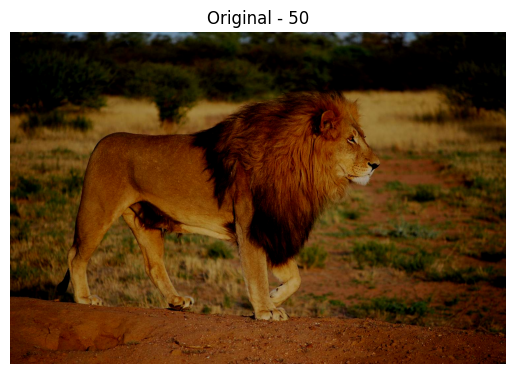

In [25]:
# Subtraction
dark = cv2.subtract(img, 50)
plt.imshow(cv2.cvtColor(dark, cv2.COLOR_BGR2RGB))
plt.title("Original - 50")
plt.axis("off")
plt.show()


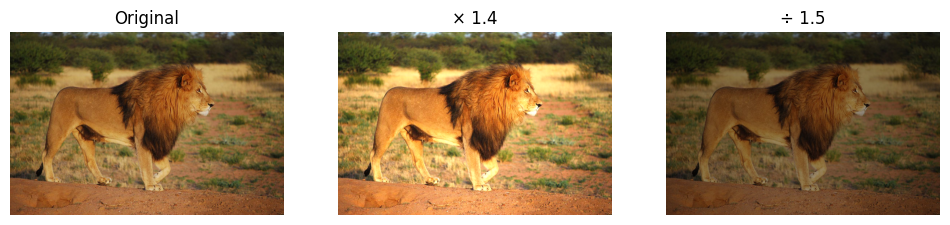

In [26]:
# Scalar multiplication and division
img_float = img.astype(np.float32)

scaled_up = np.clip(img_float * 1.4, 0, 255).astype(np.uint8)
scaled_down = np.clip(img_float / 1.5, 0, 255).astype(np.uint8)

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1); plt.imshow(img_rgb); plt.title("Original"); plt.axis("off")
plt.subplot(1, 3, 2); plt.imshow(cv2.cvtColor(scaled_up, cv2.COLOR_BGR2RGB)); plt.title("× 1.4"); plt.axis("off")
plt.subplot(1, 3, 3); plt.imshow(cv2.cvtColor(scaled_down, cv2.COLOR_BGR2RGB)); plt.title("÷ 1.5"); plt.axis("off")
plt.show()


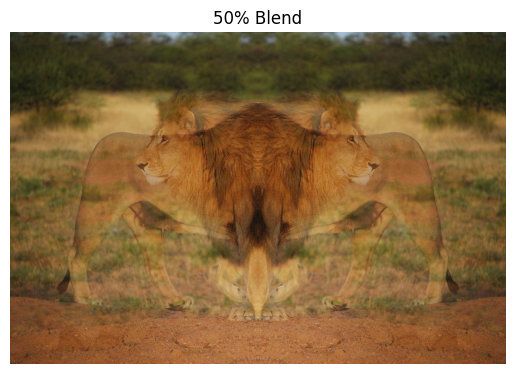

In [27]:
# Weighted blending / average
img2 = cv2.flip(img, 1)
blend = cv2.addWeighted(img, 0.5, img2, 0.5, 0)

plt.imshow(cv2.cvtColor(blend, cv2.COLOR_BGR2RGB))
plt.title("50% Blend")
plt.axis("off")
plt.show()


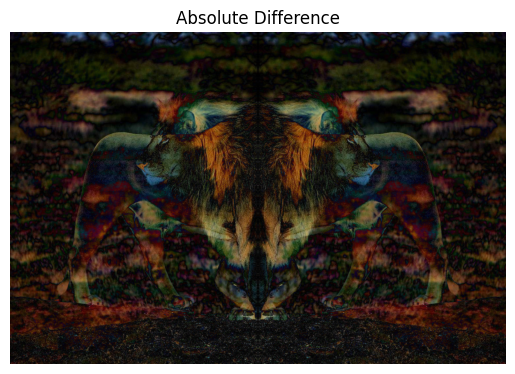

In [28]:
# Absolute difference
difference = cv2.absdiff(img, img2)

plt.imshow(cv2.cvtColor(difference, cv2.COLOR_BGR2RGB))
plt.title("Absolute Difference")
plt.axis("off")
plt.show()


## Logical / Bitwise Operations

In [29]:
a = np.array([250], dtype=np.uint8)
b = np.array([20], dtype=np.uint8)

print("NumPy uint8 result:", a + b)
print("OpenCV saturated result:", cv2.add(a, b))


NumPy uint8 result: [14]
OpenCV saturated result: [[270.]
 [  0.]
 [  0.]
 [  0.]]


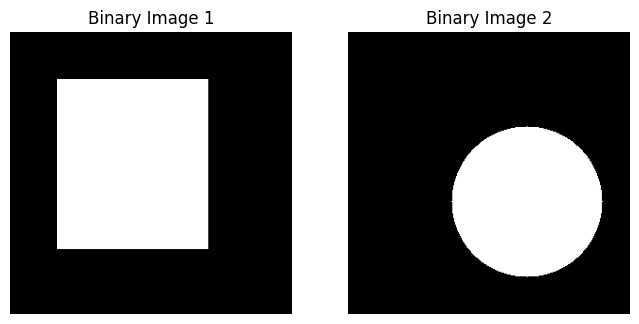

In [30]:
# Create two binary images
img1 = np.zeros((300, 300), dtype=np.uint8)
img2 = np.zeros((300, 300), dtype=np.uint8)

cv2.rectangle(img1, (50, 50), (210, 230), 255, -1)
cv2.circle(img2, (190, 180), 80, 255, -1)

plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1); plt.imshow(img1, cmap="gray"); plt.title("Binary Image 1"); plt.axis("off")
plt.subplot(1, 2, 2); plt.imshow(img2, cmap="gray"); plt.title("Binary Image 2"); plt.axis("off")
plt.show()


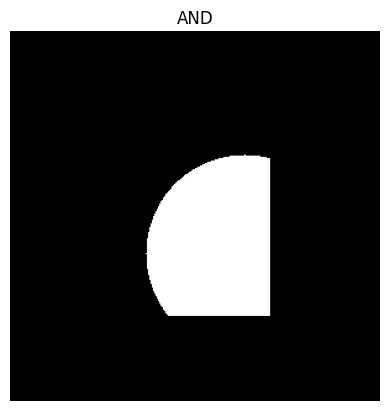

In [31]:
# AND
result = cv2.bitwise_and(img1, img2)

plt.imshow(result, cmap="gray")
plt.title("AND")
plt.axis("off")
plt.show()


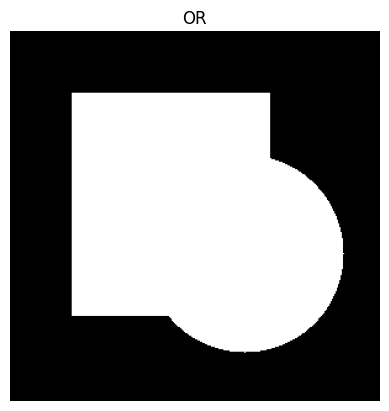

In [32]:
# OR
result = cv2.bitwise_or(img1, img2)

plt.imshow(result, cmap="gray")
plt.title("OR")
plt.axis("off")
plt.show()


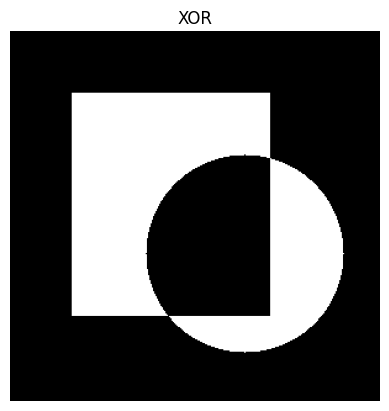

In [33]:
# XOR
result = cv2.bitwise_xor(img1, img2)

plt.imshow(result, cmap="gray")
plt.title("XOR")
plt.axis("off")
plt.show()


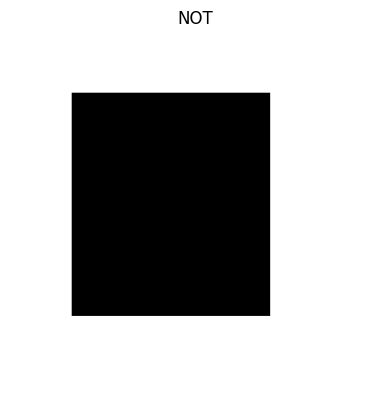

In [34]:
# NOT
result = cv2.bitwise_not(img1)

plt.imshow(result, cmap="gray")
plt.title("NOT")
plt.axis("off")
plt.show()


## Masking and Region of Interest

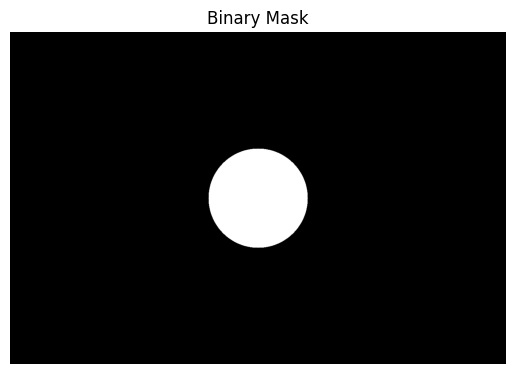

In [35]:
# Create a binary mask
mask = np.zeros(gray.shape, dtype=np.uint8)

center = (gray.shape[1] // 2, gray.shape[0] // 2)
cv2.circle(mask, center, 150, 255, -1)

plt.imshow(mask, cmap="gray")
plt.title("Binary Mask")
plt.axis("off")
plt.show()


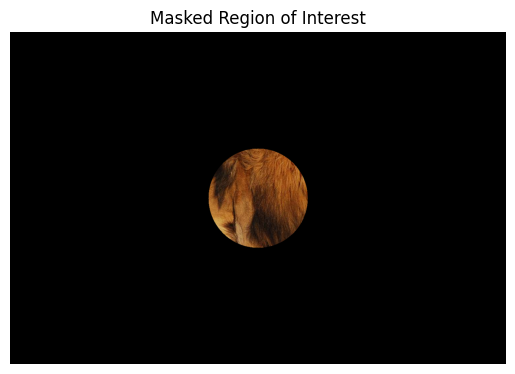

In [36]:
# Apply the mask
masked = cv2.bitwise_and(img, img, mask=mask)

plt.imshow(cv2.cvtColor(masked, cv2.COLOR_BGR2RGB))
plt.title("Masked Region of Interest")
plt.axis("off")
plt.show()
